# Experiment 8 — Stablecoin Removal

**Standalone notebook.** Requires only `data_for_experiments.csv`.

**Problem:** The existing pipeline includes stablecoins (USDT, USDC, DAI, etc.)
in the weekly cross-section. Because stablecoins have near-zero volatility by design,
they consistently rank at the bottom of the forward Sharpe distribution and receive
**Strong Avoid** labels every week. The model earns easy accuracy by correctly
predicting them as Strong Avoid, without learning anything about real crypto selection.
On the short side, the model shorts stablecoins — assets that cannot meaningfully fall.

**Fix tested:** Remove `is_stable == 1` coins from label assignment, training, and evaluation.
Labels are recomputed from scratch on the stablecoin-free cross-section.

**Outputs saved to:** `experiment_figures/`

In [2]:
from __future__ import annotations
from pathlib import Path
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')

IN_FILE = Path('Models/Data/data_for_experiments.csv')
OUT_DIR = Path('Models/Figures')

TRAIN_CUTOFF = '2024-01'
FORWARD_DAYS = 7
MIN_COINS    = 20
TOP_N        = 30

LABEL_ORDER = ['Strong Avoid', 'Avoid', 'Neutral', 'Buy', 'Strong Buy']
LABEL_MAP   = {'Strong Avoid': 0, 'Avoid': 1, 'Neutral': 2, 'Buy': 3, 'Strong Buy': 4}
BINS        = [0, 0.10, 0.30, 0.70, 0.90, 1.001]
LONG_LABEL  = 'Strong Buy'
SHORT_LABEL = 'Strong Avoid'
COLORS      = {'Strong Buy': '#1D9E75', 'Buy': '#97C459', 'Neutral': '#888780',
               'Avoid': '#F0997B', 'Strong Avoid': '#E24B4A'}
MODEL_COLORS = {'Random Forest': '#1D3A6E', 'XGBoost': '#1D9E75',
                'LightGBM': '#BA7517', 'Gradient Boosting': '#993556'}
BTC_COLOR = '#F7931A'
ETH_COLOR = '#627EEA'

LEAKY_COLS = {
    'label', 'forward_return_7d', 'forward_sharpe_7d', 'forward_sharpe_rank',
    'return_1d_rank', 'return_1d_zscore', 'return_7d_rank', 'return_7d_zscore',
    'return_30d_rank', 'return_30d_zscore', 'volatility_30d_rank', 'volatility_30d_zscore',
    'rsi_14_rank', 'rsi_14_zscore', 'macd_hist_rank', 'macd_hist_zscore',
    'bb_pct_rank', 'bb_pct_zscore', 'atr_pct_rank', 'atr_pct_zscore',
    'obv_divergence_rank', 'obv_divergence_zscore', 'stoch_k_rank', 'stoch_k_zscore',
    'adx_rank', 'adx_zscore', 'volume_vs_30d_avg_rank', 'volume_vs_30d_avg_zscore',
    'drawdown_from_90d_peak_rank', 'drawdown_from_90d_peak_zscore',
    'price_vs_ath_rank', 'price_vs_ath_zscore', 'range_position_30d_rank',
    'range_position_30d_zscore', 'consecutive_up_days_rank', 'consecutive_up_days_zscore',
    'consecutive_down_days_rank', 'consecutive_down_days_zscore',
    'coin_age_days_rank', 'coin_age_days_zscore',
    'momentum_score', 'mean_reversion_score', 'trend_score',
    'asset_id', 'year_week', 'date', 'timestamp', 'exchange',
    'pair_symbol', 'source', 'open', 'high', 'low', 'close',
    'granularity', 'is_active',
}

CS_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'atr_pct', 'obv_divergence',
    'stoch_k', 'adx', 'volume_vs_30d_avg', 'drawdown_from_90d_peak',
    'price_vs_ath', 'range_position_30d', 'consecutive_up_days',
    'consecutive_down_days', 'coin_age_days', 'galaxy_score', 'alt_rank',
    'market_cap_usd', 'coin_mcap_share_recalc', 'oi_usd', 'funding_rate',
    'taker_buy_ratio',
]

def make_models():
    return {
        'Random Forest': RandomForestClassifier(
            n_estimators=500, max_depth=12, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced',
            oob_score=True, n_jobs=-1, random_state=42),
        'XGBoost': XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='mlogloss', verbosity=0,
            random_state=42, n_jobs=-1),
        'LightGBM': LGBMClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            class_weight='balanced', random_state=42,
            n_jobs=-1, verbose=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            random_state=42),
    }

print('Config loaded.')

Config loaded.


## 1. Load data and build weekly labels — WITH stablecoins (baseline)

In [2]:
df = pd.read_csv(IN_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['asset_id', 'date']).reset_index(drop=True)
df['year_week'] = df['date'].dt.strftime('%G-W%V')
print(f'Loaded: {df.shape[0]:,} rows | {df["asset_id"].nunique()} coins')
print(f'Range : {df["date"].min().date()} -> {df["date"].max().date()}')

def compute_forward_sharpe_7d(group):
    closes, results = group['close'].values, []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan); continue
        window     = closes[i:end]
        daily_rets = np.diff(window) / window[:-1]
        fwd_ret    = (window[-1] - window[0]) / window[0]
        vol        = daily_rets.std() * np.sqrt(365)
        results.append((fwd_ret / vol) if vol > 1e-8 else 0.0)
    return pd.Series(results, index=group.index)

print('Computing forward Sharpe...')
df['forward_sharpe_7d'] = df.groupby('asset_id', group_keys=False).apply(compute_forward_sharpe_7d)
df['forward_return_7d'] = df.groupby('asset_id')['close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1)

def build_weekly_snapshots(data):
    return (
        data.dropna(subset=['forward_sharpe_7d'])
        .sort_values('date')
        .groupby(['asset_id', 'year_week']).last().reset_index()
    )

def assign_labels(group):
    if len(group) < MIN_COINS:
        return group.assign(label=np.nan, forward_sharpe_rank=np.nan)
    q = group['forward_sharpe_7d'].rank(pct=True)
    group = group.copy()
    group['forward_sharpe_rank'] = q
    group['label'] = pd.cut(q, bins=BINS, labels=LABEL_ORDER, include_lowest=True)
    return group

def label_weekly(snapshots):
    return (
        snapshots.groupby('year_week', group_keys=False).apply(assign_labels)
        .dropna(subset=['label']).reset_index(drop=True)
    )

# Baseline: ALL coins including stablecoins
weekly_with = label_weekly(build_weekly_snapshots(df))
print(f'\n[WITH stablecoins] {len(weekly_with):,} rows, {weekly_with["asset_id"].nunique()} coins')
print('Label distribution:')
print(weekly_with['label'].value_counts()[LABEL_ORDER].to_string())

Loaded: 211,498 rows | 164 coins
Range : 2019-03-04 -> 2026-03-01
Computing forward Sharpe...

[WITH stablecoins] 30,050 rows, 162 coins
Label distribution:
label
Strong Avoid     2878
Avoid            5979
Neutral         12005
Buy              5980
Strong Buy       3208


## 2. Identify and remove stablecoins — WITHOUT stablecoins (filtered)

In [ ]:
if 'is_stable' in df.columns:
    stable_ids = set(df[df['is_stable'] == 1]['asset_id'].unique())
    print(f'Stablecoins identified via is_stable flag: {len(stable_ids)}')
else:
    coin_vol   = df.groupby('asset_id')['return_1d'].std()
    stable_ids = set(coin_vol[coin_vol < 0.002].index.tolist())
    print(f'No is_stable column — identified {len(stable_ids)} stablecoins by return std < 0.2%')

for s in sorted(stable_ids):
    print(f'  - {s}')

df_no_stable = df[~df['asset_id'].isin(stable_ids)].copy()
print(f'\nRaw data after removal: {df_no_stable["asset_id"].nunique()} coins')

weekly_no = label_weekly(build_weekly_snapshots(df_no_stable))
print(f'[WITHOUT stablecoins] {len(weekly_no):,} rows, {weekly_no["asset_id"].nunique()} coins')
print('Label distribution (filtered):')
print(weekly_no['label'].value_counts()[LABEL_ORDER].to_string())
print(f'\nRows removed: {len(weekly_with) - len(weekly_no):,}')

Stablecoins identified via is_stable flag: 11
  - bfusd
  - dai
  - falcon-finance-ff
  - first-digital-usd
  - frax
  - pax-gold
  - paypal-usd
  - ripple-usd
  - stable-2
  - true-usd
  - usd1-wlfi

Raw data after removal: 153 coins
[WITHOUT stablecoins] 28,754 rows, 151 coins
Label distribution (filtered):
label
Strong Avoid     2720
Avoid            5751
Neutral         11530
Buy              5750
Strong Buy       3003

Rows removed: 1,296


## 3. Cross-sectional features, train/test split, feature selection

In [ ]:
def build_features_and_split(weekly):
    """Build CS features, split train/test, filter candidate features."""
    w = weekly.copy()
    cs_cols = [c for c in CS_FEATURES if c in w.columns]
    for col in cs_cols:
        w[f'{col}_rank']   = w.groupby('year_week')[col].transform(lambda x: x.rank(pct=True))
        w[f'{col}_zscore'] = w.groupby('year_week')[col].transform(
            lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))

    cutoff = pd.Timestamp(TRAIN_CUTOFF + '-01')
    tr = w[pd.to_datetime(w['date']) <  cutoff].copy()
    te = w[pd.to_datetime(w['date']) >= cutoff].copy()

    all_feats = [
        c for c in w.columns
        if c not in LEAKY_COLS
        and w[c].dtype in [np.float64, np.float32, np.int64, np.int32]
    ]
    null_rates = tr[all_feats].isnull().mean()
    all_feats  = [f for f in all_feats if null_rates[f] <= 0.30]

    y_tr = tr['label'].map(LABEL_MAP)
    y_te = te['label'].map(LABEL_MAP)
    return tr, te, all_feats, y_tr, y_te

def prep(d, cols):
    return d[cols].fillna(0).replace([np.inf, -np.inf], 0).clip(-1e9, 1e9)

print('Building features for WITH-stablecoins dataset...')
train_with, test_with, feats_with, y_train_with, y_test_with = build_features_and_split(weekly_with)
print(f'  Train: {len(train_with):,} | Test: {len(test_with):,} | Features: {len(feats_with)}')

print('Building features for WITHOUT-stablecoins dataset...')
train_no, test_no, feats_no, y_train_no, y_test_no = build_features_and_split(weekly_no)
print(f'  Train: {len(train_no):,} | Test: {len(test_no):,} | Features: {len(feats_no)}')

test_start = pd.Timestamp(TRAIN_CUTOFF + '-01')
btc_w = df[df['asset_id']=='bitcoin'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]
eth_w = df[df['asset_id']=='ethereum'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]

def select_top30(tr, all_feats, y_tr, label):
    print(f'  RF pass-1 ({label})...')
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                 max_features='sqrt', class_weight='balanced',
                                 oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(prep(tr, all_feats), y_tr)
    imp = pd.Series(rf.feature_importances_, index=all_feats).sort_values(ascending=False)
    top = imp.head(TOP_N).index.tolist()
    print(f'  OOB: {rf.oob_score_*100:.2f}%  |  top-30 selected')
    return top

print('Running RF feature selection...')
top30_with = select_top30(train_with, feats_with, y_train_with, 'with stablecoins')
top30_no   = select_top30(train_no,   feats_no,   y_train_no,   'without stablecoins')

print(f'\nTop-30 overlap between the two datasets: {len(set(top30_with) & set(top30_no))} / 30 features')

Building features for WITH-stablecoins dataset...
  Train: 15,651 | Test: 14,399 | Features: 103
Building features for WITHOUT-stablecoins dataset...
  Train: 15,068 | Test: 13,686 | Features: 103
Running RF feature selection...
  RF pass-1 (with stablecoins)...
  OOB: 28.85%  |  top-30 selected
  RF pass-1 (without stablecoins)...
  OOB: 28.38%  |  top-30 selected

Top-30 overlap between the two datasets: 27 / 30 features


## 4. Shared utilities

In [5]:
def run_all_models(feats, tr, te, y_tr, y_te):
    results = {}
    for name, clf in make_models().items():
        t0 = time.time()
        clf.fit(prep(tr, feats), y_tr)
        y_pred = clf.predict(prep(te, feats))
        acc    = accuracy_score(y_te, y_pred)
        macro  = f1_score(y_te, y_pred, average='macro')
        print(f'  {name:<22} acc={acc*100:.2f}%  F1={macro*100:.2f}%  ({time.time()-t0:.1f}s)')
        results[name] = (clf, y_pred, acc, macro)
    return results

def bucket_stats(y_pred_array, df):
    labels = pd.Series([LABEL_ORDER[p] for p in y_pred_array], index=df.index)
    rows = []
    for lbl in LABEL_ORDER:
        b = df[labels == lbl]['forward_return_7d']
        rows.append({'label': lbl, 'n': len(b), 'avg': b.mean()*100,
                     'median': b.median()*100, 'pct_pos': (b>0).mean()*100})
    return pd.DataFrame(rows)

def spread_stats(y_pred_array, df):
    labels = pd.Series([LABEL_ORDER[p] for p in y_pred_array], index=df.index)
    spreads = []
    for wk in sorted(df['year_week'].unique()):
        m = df[df['year_week'] == wk]
        l = labels[m.index]
        lr = m[l == LONG_LABEL]['forward_return_7d'].median()
        sr = m[l == SHORT_LABEL]['forward_return_7d'].median()
        if pd.notna(lr) and pd.notna(sr):
            spreads.append(lr - sr)
    s = pd.Series(spreads)
    return {'avg_spread': s.mean()*100, 'win_rate': (s>0).mean()*100, 'ann': s.mean()*52*100}

def cumret(s):
    return (1 + s.fillna(0)).cumprod()

def get_cum_legs(y_pred_array, df):
    labels = pd.Series([LABEL_ORDER[p] for p in y_pred_array], index=df.index)
    rows = []
    for wk in sorted(df['year_week'].unique()):
        m = df[df['year_week'] == wk]
        l = labels[m.index]
        lr = m[l == LONG_LABEL]['forward_return_7d'].median()
        sr = m[l == SHORT_LABEL]['forward_return_7d'].median()
        rows.append({
            'long':  lr if pd.notna(lr) else 0.0,
            'short': sr if pd.notna(sr) else 0.0,
            'net':   (lr - sr) if (pd.notna(lr) and pd.notna(sr)) else np.nan,
        })
    return pd.DataFrame(rows)

def is_monotonic(y_pred_array, df):
    vals = bucket_stats(y_pred_array, df)['avg'].tolist()
    return all(vals[i] <= vals[i+1] for i in range(len(vals)-1))

print('Utilities ready.')

Utilities ready.


## 5. Train — baseline (with stablecoins)

In [6]:
print('Training all models — WITH stablecoins (top-30)...')
res_with = run_all_models(top30_with, train_with, test_with, y_train_with, y_test_with)

print('\nBucket returns (with stablecoins, XGBoost):')
print(bucket_stats(res_with['XGBoost'][1], test_with).round(2).to_string(index=False))
sp_with = spread_stats(res_with['XGBoost'][1], test_with)
print(f"Spread: {sp_with['avg_spread']:+.2f}%  Win rate: {sp_with['win_rate']:.0f}%")

Training all models — WITH stablecoins (top-30)...
  Random Forest          acc=34.49%  F1=24.66%  (4.8s)
  XGBoost                acc=38.17%  F1=18.84%  (4.6s)
  LightGBM               acc=29.14%  F1=23.24%  (6.7s)
  Gradient Boosting      acc=36.39%  F1=19.73%  (283.5s)

Bucket returns (with stablecoins, XGBoost):
       label     n   avg  median  pct_pos
Strong Avoid   497 -1.45   -0.05    38.03
       Avoid   769 -1.53   -2.18    40.31
     Neutral 11926  0.06   -1.37    43.77
         Buy  1005  0.85    0.00    49.95
  Strong Buy   202  5.08    0.02    53.47
Spread: +6.42%  Win rate: 72%


## 6. Train — filtered (without stablecoins)

In [7]:
print('Training all models — WITHOUT stablecoins (top-30)...')
res_no = run_all_models(top30_no, train_no, test_no, y_train_no, y_test_no)

print('\nBucket returns (no stablecoins, XGBoost):')
print(bucket_stats(res_no['XGBoost'][1], test_no).round(2).to_string(index=False))
sp_no = spread_stats(res_no['XGBoost'][1], test_no)
print(f"Spread: {sp_no['avg_spread']:+.2f}%  Win rate: {sp_no['win_rate']:.0f}%")

Training all models — WITHOUT stablecoins (top-30)...
  Random Forest          acc=33.56%  F1=24.13%  (4.8s)
  XGBoost                acc=37.62%  F1=17.11%  (4.4s)
  LightGBM               acc=28.67%  F1=22.35%  (6.4s)
  Gradient Boosting      acc=36.48%  F1=18.07%  (266.7s)

Bucket returns (no stablecoins, XGBoost):
       label     n   avg  median  pct_pos
Strong Avoid   253 -2.83   -5.93    36.36
       Avoid   825 -0.20   -2.28    42.42
     Neutral 11445  0.03   -1.62    43.47
         Buy  1013  0.38   -0.51    47.58
  Strong Buy   150  5.02    0.02    50.00
Spread: +9.59%  Win rate: 70%


## 7. Classification report comparison

In [8]:
model_names = list(res_with.keys())

print(f'{"Model":<22}  {"Acc WITH":>9}  {"Acc NO":>9}  {"Δ acc":>8}  '
      f'{"Spr WITH":>9}  {"Spr NO":>9}  {"Δ spr":>8}  {"WR WITH":>8}  {"WR NO":>8}')
print('-' * 105)

rows_cmp = []
for mname in model_names:
    _, yw, aw, mw = res_with[mname]
    _, yn, an, mn = res_no[mname]
    sw = spread_stats(yw, test_with)
    sn = spread_stats(yn, test_no)
    d_acc = (an - aw) * 100
    d_spr = sn['avg_spread'] - sw['avg_spread']
    print(f'{mname:<22}  {aw*100:>8.2f}%  {an*100:>8.2f}%  {d_acc:>+7.2f}pp  '
          f'{sw["avg_spread"]:>+8.2f}%  {sn["avg_spread"]:>+8.2f}%  {d_spr:>+7.2f}pp  '
          f'{sw["win_rate"]:>7.0f}%  {sn["win_rate"]:>7.0f}%')
    rows_cmp.append({
        'Model': mname,
        'Acc with (%)':      round(aw*100, 2),
        'Acc no (%)':        round(an*100, 2),
        'Acc change (pp)':   round(d_acc, 2),
        'Spread with (%)':   round(sw['avg_spread'], 2),
        'Spread no (%)':     round(sn['avg_spread'], 2),
        'Spread change (pp)': round(d_spr, 2),
        'Win rate with (%)': round(sw['win_rate'], 1),
        'Win rate no (%)':   round(sn['win_rate'], 1),
    })

cmp_df = pd.DataFrame(rows_cmp)
cmp_df.to_csv(DYPLOM / 'exp8_stablecoin_comparison.csv', index=False)
print(f'\nSaved -> exp8_stablecoin_comparison.csv')

print('\n--- XGBoost classification report (WITH stablecoins) ---')
print(classification_report(y_test_with, res_with['XGBoost'][1], target_names=LABEL_ORDER))
print('--- XGBoost classification report (WITHOUT stablecoins) ---')
print(classification_report(y_test_no, res_no['XGBoost'][1], target_names=LABEL_ORDER))

Model                    Acc WITH     Acc NO     Δ acc   Spr WITH     Spr NO     Δ spr   WR WITH     WR NO
---------------------------------------------------------------------------------------------------------
Random Forest              34.49%     33.56%    -0.93pp     +2.45%     +2.97%    +0.52pp       67%       73%
XGBoost                    38.17%     37.62%    -0.55pp     +6.42%     +9.59%    +3.17pp       72%       70%
LightGBM                   29.14%     28.67%    -0.47pp     +1.96%     +1.69%    -0.26pp       71%       62%
Gradient Boosting          36.39%     36.48%    +0.08pp     +1.29%     +5.88%    +4.59pp       57%       62%

Saved -> exp8_stablecoin_comparison.csv

--- XGBoost classification report (WITH stablecoins) ---
              precision    recall  f1-score   support

Strong Avoid       0.23      0.08      0.12      1397
       Avoid       0.21      0.06      0.09      2871
     Neutral       0.42      0.86      0.56      5756
         Buy       0.20      0.07  

## 8. Figure 1 — Metric comparison: with vs without stablecoins

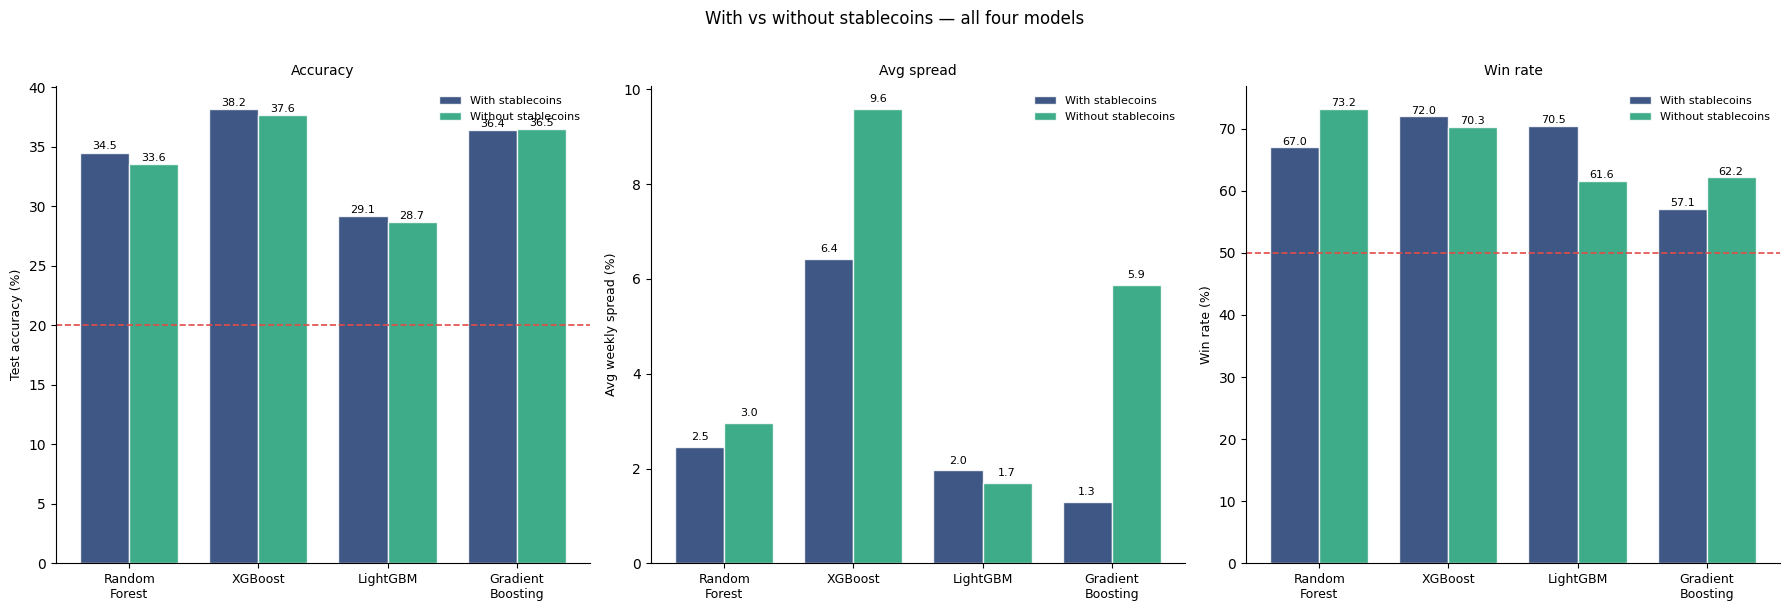

Saved -> exp8_metric_comparison.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

m_labels = [m.replace(' ', '\n') for m in model_names]
x        = np.arange(len(model_names))
width    = 0.38
c_with   = '#1D3A6E'
c_no     = '#1D9E75'

for ax, col_w, col_n, ylabel, title, bl in [
    (axes[0], 'Acc with (%)',     'Acc no (%)',     'Test accuracy (%)',     'Accuracy', 20),
    (axes[1], 'Spread with (%)',  'Spread no (%)',  'Avg weekly spread (%)', 'Avg spread', None),
    (axes[2], 'Win rate with (%)', 'Win rate no (%)', 'Win rate (%)',        'Win rate', 50),
]:
    vals_w = cmp_df[col_w].tolist()
    vals_n = cmp_df[col_n].tolist()
    b1 = ax.bar(x - width/2, vals_w, width, label='With stablecoins',
                color=c_with, alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + width/2, vals_n, width, label='Without stablecoins',
                color=c_no,   alpha=0.85, edgecolor='white')
    if bl is not None:
        ax.axhline(bl, color='#E24B4A', lw=1.2, ls='--')
    ax.axhline(0, color='#888780', lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(m_labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='500', pad=8)
    ax.legend(fontsize=8, framealpha=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    for b, v in zip(list(b1) + list(b2), vals_w + vals_n):
        off = 0.1 if v >= 0 else -0.5
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + off,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('With vs without stablecoins — all four models',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'exp8_metric_comparison.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {p.name}')

## 9. Figure 2 — Change in accuracy and spread (delta bars)

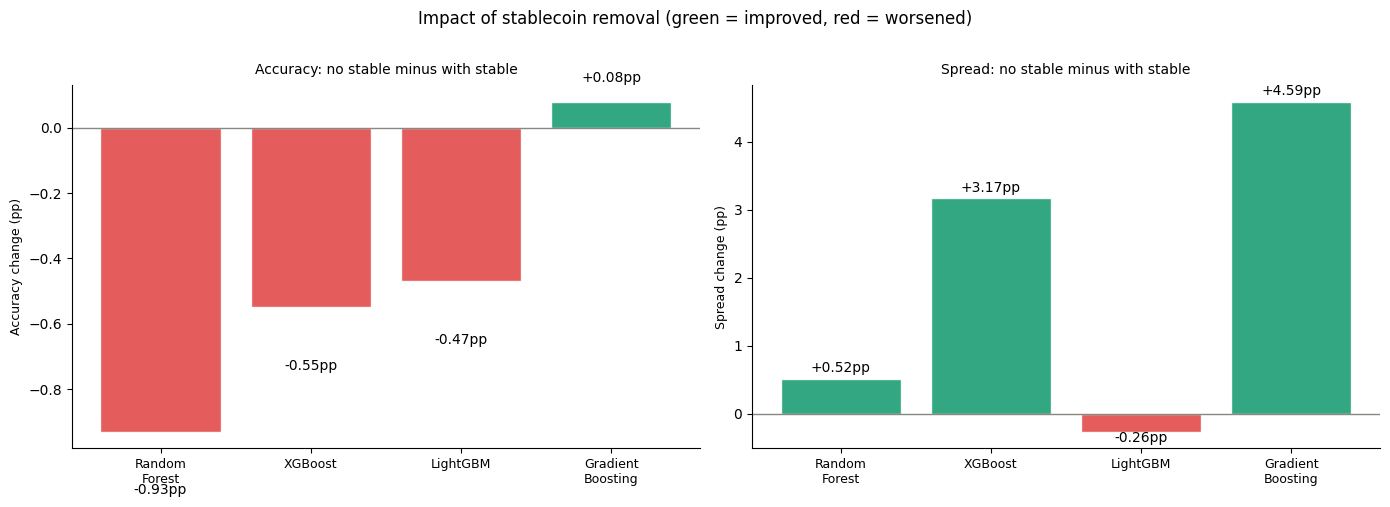

Saved -> exp8_delta_bars.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

for ax, col, ylabel, title in [
    (axes[0], 'Acc change (pp)',    'Accuracy change (pp)', 'Accuracy: no stable minus with stable'),
    (axes[1], 'Spread change (pp)', 'Spread change (pp)',   'Spread: no stable minus with stable'),
]:
    vals     = cmp_df[col].tolist()
    bcolors  = ['#1D9E75' if v >= 0 else '#E24B4A' for v in vals]
    bars     = ax.bar(x, vals, color=bcolors, alpha=0.9, edgecolor='white')
    ax.axhline(0, color='#888780', lw=1.0)
    ax.set_xticks(x); ax.set_xticklabels(m_labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='500', pad=8)
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
    for b, v in zip(bars, vals):
        off = 0.05 if v >= 0 else -0.2
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+off,
                f'{v:+.2f}pp', ha='center', va='bottom', fontsize=10, fontweight='500')

plt.suptitle('Impact of stablecoin removal (green = improved, red = worsened)',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'exp8_delta_bars.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 10. Figure 3 — Bucket return profiles: with vs without

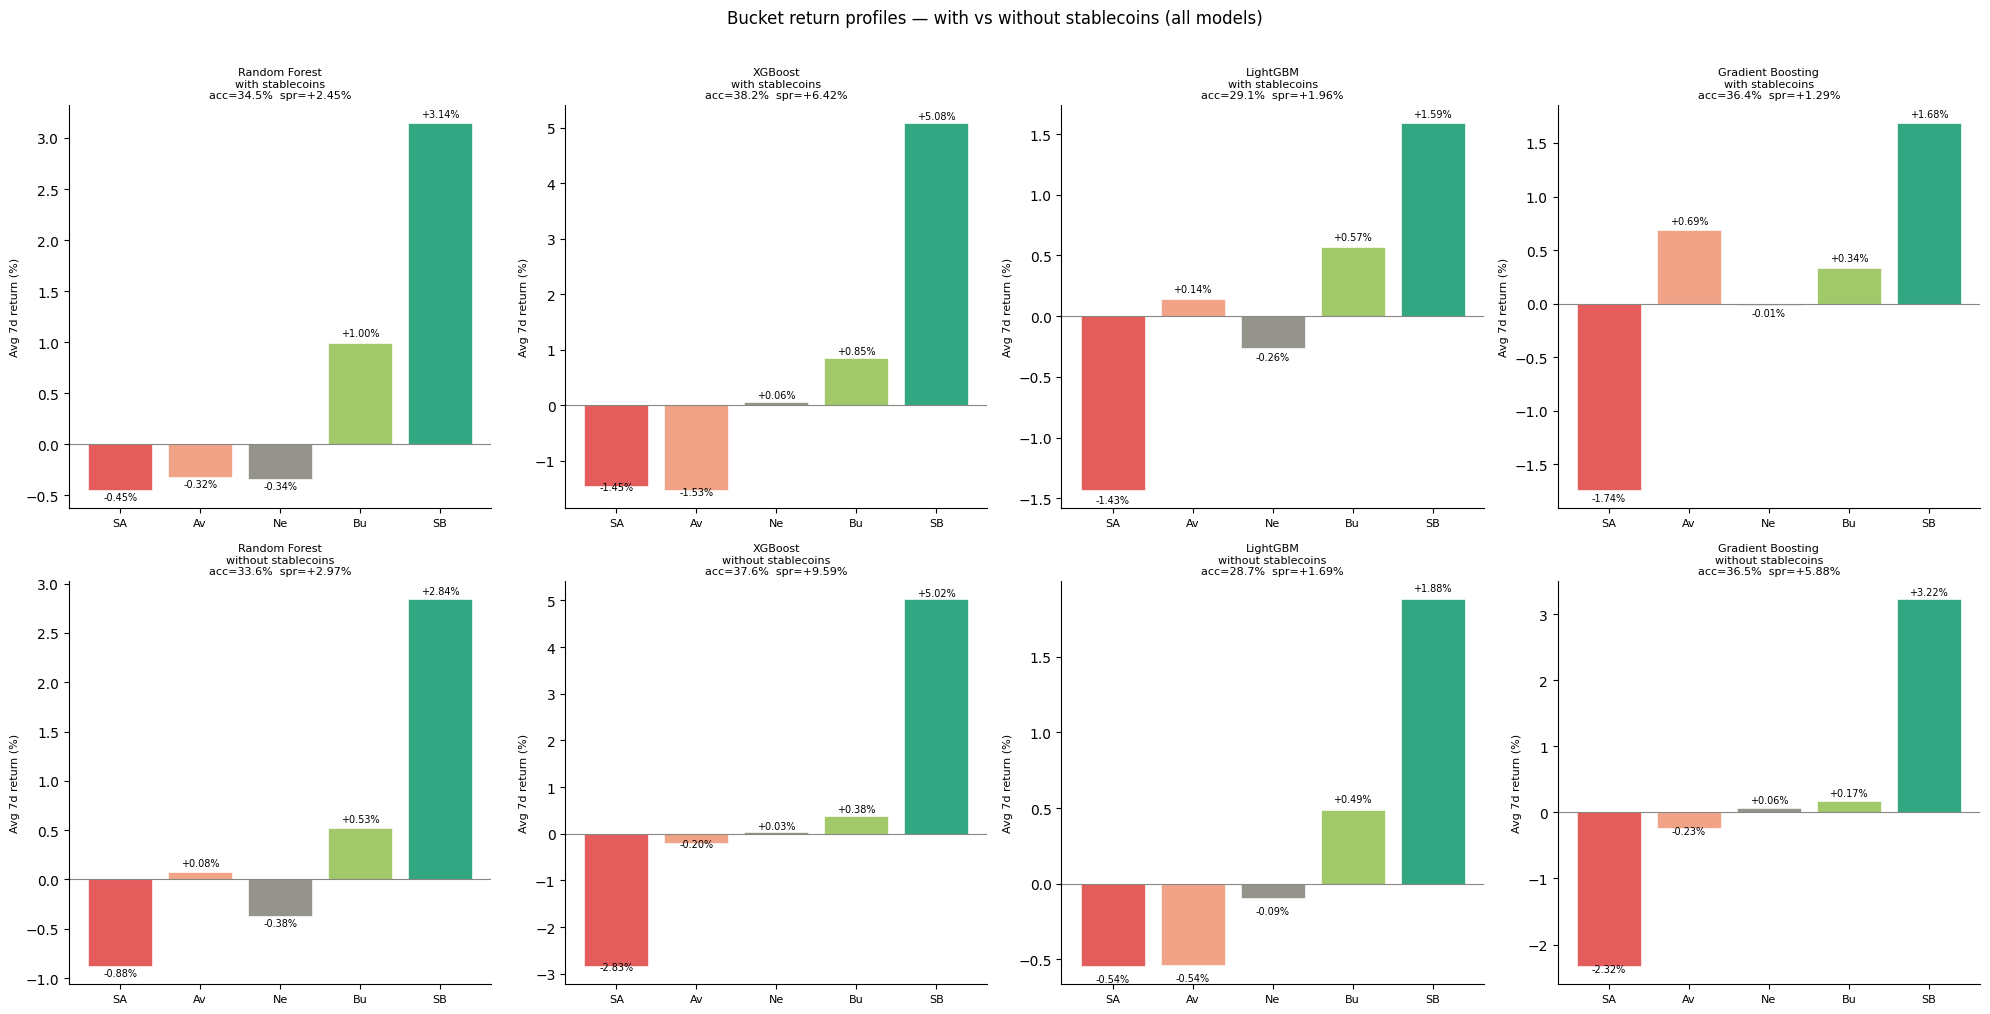

Saved -> exp8_bucket_profiles.png


In [11]:
bucket_colors = [COLORS[l] for l in LABEL_ORDER]

fig, axes = plt.subplots(2, len(model_names), figsize=(5*len(model_names), 10))
fig.patch.set_facecolor('white')

for col_idx, mname in enumerate(model_names):
    for row_idx, (res, te, title_sfx) in enumerate([
        (res_with, test_with, 'with stablecoins'),
        (res_no,   test_no,   'without stablecoins'),
    ]):
        ax  = axes[row_idx][col_idx]
        _, ypred, acc, _ = res[mname]
        bdf = bucket_stats(ypred, te)
        sp  = spread_stats(ypred, te)
        bars = ax.bar(range(len(LABEL_ORDER)), bdf['avg'], color=bucket_colors,
                      edgecolor='white', linewidth=0.5, alpha=0.9)
        ax.axhline(0, color='#888780', lw=0.8)
        ax.set_xticks(range(len(LABEL_ORDER)))
        ax.set_xticklabels(['SA','Av','Ne','Bu','SB'], fontsize=8)
        ax.set_title(f'{mname}\n{title_sfx}\nacc={acc*100:.1f}%  spr={sp["avg_spread"]:+.2f}%',
                     fontsize=8, fontweight='500', pad=5)
        ax.set_ylabel('Avg 7d return (%)', fontsize=8)
        ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
        for bar, val in zip(bars, bdf['avg']):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+(0.04 if val>=0 else -0.12),
                    f'{val:+.2f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Bucket return profiles — with vs without stablecoins (all models)',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'exp8_bucket_profiles.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 11. Figure 4 — Cumulative L/S, long-only, short-only (XGBoost only)

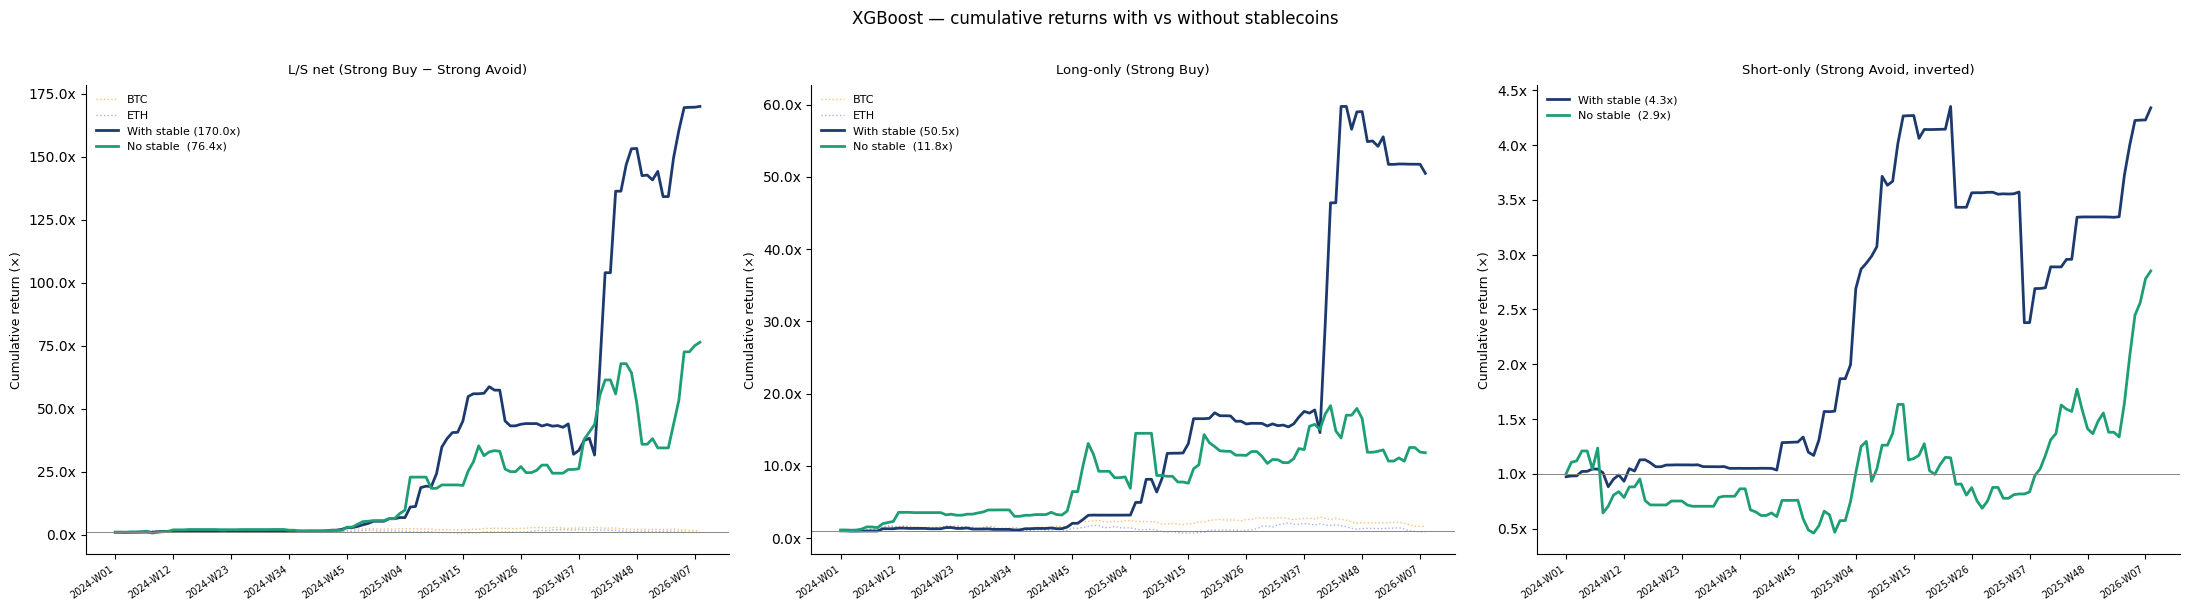

Saved -> exp8_cumulative_legs.png


In [12]:
legs_with_xgb = get_cum_legs(res_with['XGBoost'][1], test_with)
legs_no_xgb   = get_cum_legs(res_no['XGBoost'][1],   test_no)

n_w = len(legs_with_xgb)
n_n = len(legs_no_xgb)
btc_c = cumret(btc_w.reset_index(drop=True).iloc[:max(n_w, n_n)])
eth_c = cumret(eth_w.reset_index(drop=True).iloc[:max(n_w, n_n)])

wk_labels = sorted(test_with['year_week'].unique())
step = max(1, len(wk_labels)//10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('white')

leg_configs = [
    ('net',   'L/S net (Strong Buy − Strong Avoid)'),
    ('long',  'Long-only (Strong Buy)'),
    ('short', 'Short-only (Strong Avoid, inverted)'),
]

for ax, (leg_key, leg_title) in zip(axes, leg_configs):
    if leg_key != 'short':
        ax.plot(range(len(btc_c)), btc_c.values, color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
        ax.plot(range(len(eth_c)), eth_c.values, color=ETH_COLOR, lw=1.0, ls=':', alpha=0.6, label='ETH')

    series_w = legs_with_xgb[leg_key] if leg_key != 'short' else -legs_with_xgb['short']
    series_n = legs_no_xgb[leg_key]   if leg_key != 'short' else -legs_no_xgb['short']

    cum_w = cumret(series_w)
    cum_n = cumret(series_n)

    ax.plot(range(n_w), cum_w.values, color='#1D3A6E', lw=2.0,
            label=f'With stable ({cum_w.values[-1]:.1f}x)')
    ax.plot(range(n_n), cum_n.values, color='#1D9E75', lw=2.0,
            label=f'No stable  ({cum_n.values[-1]:.1f}x)')
    ax.axhline(1.0, color='#888780', lw=0.7)

    ax.set_xticks(range(0, len(wk_labels), step))
    ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.1f}x'))
    ax.set_ylabel('Cumulative return (×)', fontsize=9)
    ax.set_title(leg_title, fontsize=9.5, fontweight='500', pad=8)
    ax.legend(fontsize=8, framealpha=0, loc='upper left')
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')

plt.suptitle('XGBoost — cumulative returns with vs without stablecoins',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'exp8_cumulative_legs.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

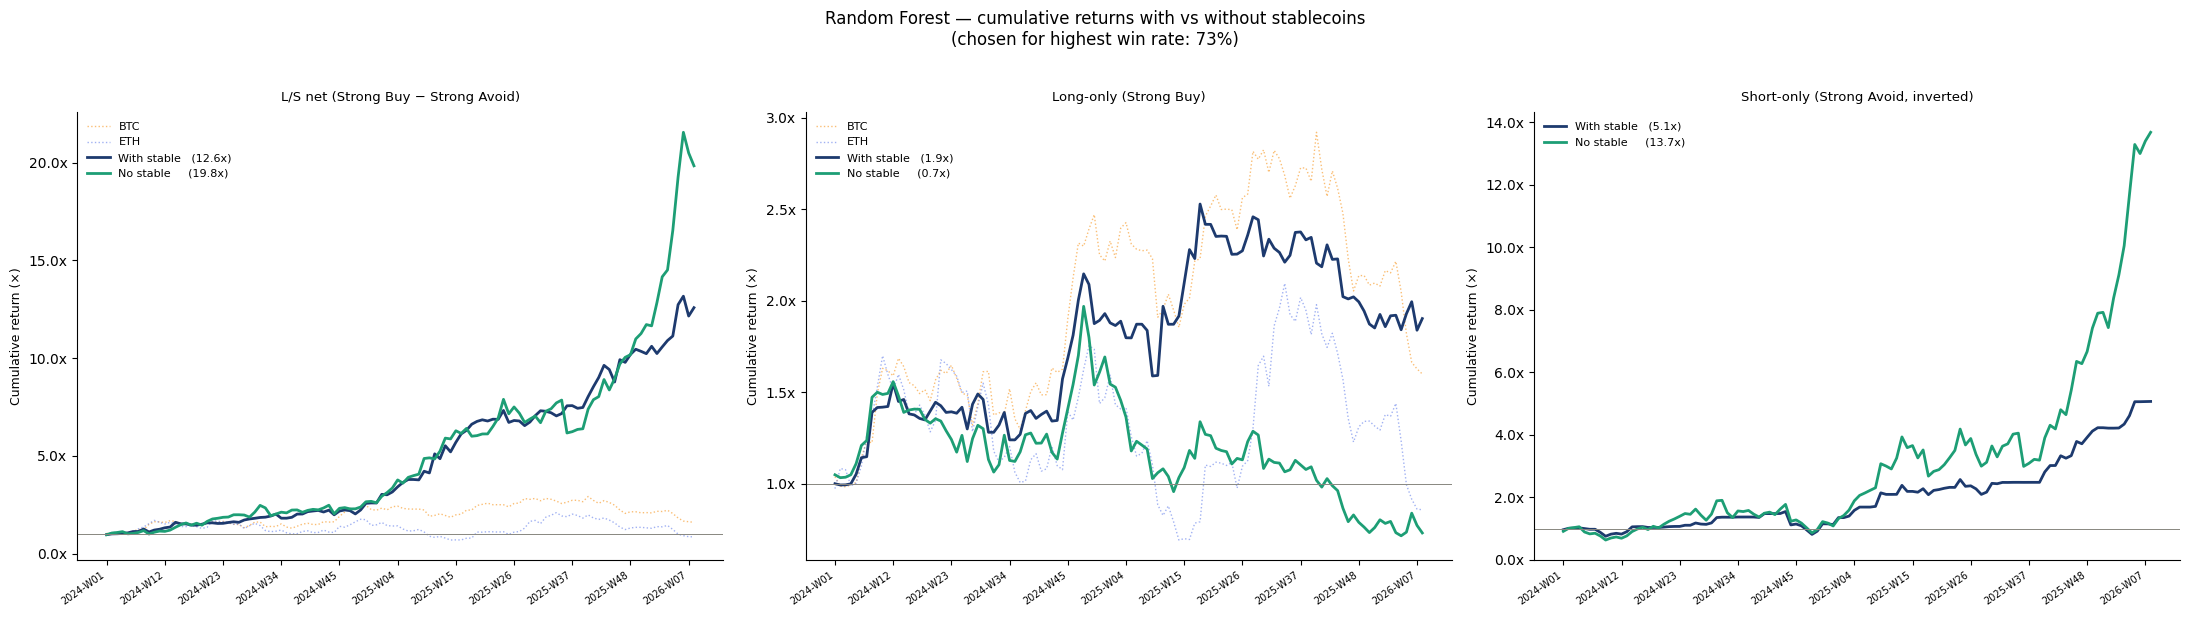

Saved -> exp8_rf_cumulative.png
With stablecoins: net=12.6x  long=1.9x  short=5.1x  spread=+2.45%  win=67%
Without stablecoins: net=19.8x  long=0.7x  short=13.7x  spread=+2.97%  win=73%


In [ ]:
# Cumulative return — Random Forest with vs without stablecoins (all three legs)
legs_with_rf = get_cum_legs(res_with['Random Forest'][1], test_with)
legs_no_rf   = get_cum_legs(res_no['Random Forest'][1],   test_no)

n_w = len(legs_with_rf)
n_n = len(legs_no_rf)
btc_c = cumret(btc_w.reset_index(drop=True).iloc[:max(n_w, n_n)])
eth_c = cumret(eth_w.reset_index(drop=True).iloc[:max(n_w, n_n)])

wk_labels = sorted(test_with['year_week'].unique())
step = max(1, len(wk_labels) // 10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('white')

leg_configs = [
    ('net',   'L/S net (Strong Buy − Strong Avoid)'),
    ('long',  'Long-only (Strong Buy)'),
    ('short', 'Short-only (Strong Avoid, inverted)'),
]

for ax, (leg_key, leg_title) in zip(axes, leg_configs):
    if leg_key != 'short':
        ax.plot(range(len(btc_c)), btc_c.values,
                color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
        ax.plot(range(len(eth_c)), eth_c.values,
                color=ETH_COLOR, lw=1.0, ls=':', alpha=0.6, label='ETH')

    s_w = legs_with_rf[leg_key] if leg_key != 'short' else -legs_with_rf['short']
    s_n = legs_no_rf[leg_key]   if leg_key != 'short' else -legs_no_rf['short']

    cum_w = cumret(s_w)
    cum_n = cumret(s_n)

    ax.plot(range(n_w), cum_w.values, color='#1D3A6E', lw=2.0,
            label=f'With stable   ({cum_w.values[-1]:.1f}x)')
    ax.plot(range(n_n), cum_n.values, color='#1D9E75', lw=2.0,
            label=f'No stable     ({cum_n.values[-1]:.1f}x)')
    ax.axhline(1.0, color='#888780', lw=0.7)

    ax.set_xticks(range(0, len(wk_labels), step))
    ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.1f}x'))
    ax.set_ylabel('Cumulative return (×)', fontsize=9)
    ax.set_title(leg_title, fontsize=9.5, fontweight='500', pad=8)
    ax.legend(fontsize=8, framealpha=0, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')

plt.suptitle('Random Forest — cumulative returns with vs without stablecoins\n(chosen for highest win rate: 73%)',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()
p = OUT_DIR / 'exp8_rf_cumulative.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {p.name}')

for label, legs, te, res in [
    ('With stablecoins',    legs_with_rf, test_with, res_with),
    ('Without stablecoins', legs_no_rf,   test_no,   res_no),
]:
    sp = spread_stats(res['Random Forest'][1], te)
    print(f'{label}: net={cumret(legs["net"]).values[-1]:.1f}x  '
          f'long={cumret(legs["long"]).values[-1]:.1f}x  '
          f'short={cumret(-legs["short"]).values[-1]:.1f}x  '
          f'spread={sp["avg_spread"]:+.2f}%  win={sp["win_rate"]:.0f}%')

## 12. Final summary

In [13]:
print('='*80)
print('EXPERIMENT 8 — STABLECOIN REMOVAL SUMMARY (XGBoost)')
print('='*80)

_, yw, aw, _ = res_with['XGBoost']
_, yn, an, _ = res_no['XGBoost']
sw = spread_stats(yw, test_with)
sn = spread_stats(yn, test_no)
bw = bucket_stats(yw, test_with)
bn = bucket_stats(yn, test_no)

print(f'\n  Dataset          Coins   Accuracy   Spread    Win rate   Monotonic')
print(f'  With stables     {test_with["asset_id"].nunique():>5}   {aw*100:.2f}%    {sw["avg_spread"]:+.2f}%   {sw["win_rate"]:.0f}%        {is_monotonic(yw, test_with)}')
print(f'  Without stables  {test_no["asset_id"].nunique():>5}   {an*100:.2f}%    {sn["avg_spread"]:+.2f}%   {sn["win_rate"]:.0f}%        {is_monotonic(yn, test_no)}')

d_acc = (an - aw) * 100
d_spr = sn['avg_spread'] - sw['avg_spread']
print(f'\n  Change:          {'':>5}  {d_acc:+.2f}pp    {d_spr:+.2f}pp')

print('\nInterpretation:')
if d_acc < -1:
    print(f'  Accuracy dropped {d_acc:.2f}pp — stablecoins were inflating classification '
          f'by providing trivially predictable Strong Avoid labels.')
elif d_acc > 1:
    print(f'  Accuracy improved {d_acc:.2f}pp — removing stablecoins made the classification task cleaner.')
else:
    print(f'  Accuracy change is minimal ({d_acc:.2f}pp) — stablecoins had little impact on classification.')

if d_spr > 0.2:
    print(f'  Spread improved {d_spr:.2f}pp — the economic signal is stronger without stablecoin noise.')
elif d_spr < -0.2:
    print(f'  Spread dropped {d_spr:.2f}pp — stablecoins contributed to short-leg profits '
          f'(the short of stablecoins earned small but consistent gains).')
else:
    print(f'  Spread change is small ({d_spr:.2f}pp).')

print('\n=== Output files ===')
for f in sorted(OUT_DIR.iterdir()):
    if 'exp8' in f.name:
        print(f'  {f.name}')

EXPERIMENT 8 — STABLECOIN REMOVAL SUMMARY (XGBoost)

  Dataset          Coins   Accuracy   Spread    Win rate   Monotonic
  With stables       161   38.17%    +6.42%   72%        False
  Without stables    150   37.62%    +9.59%   70%        True

  Change:                 -0.55pp    +3.17pp

Interpretation:
  Accuracy change is minimal (-0.55pp) — stablecoins had little impact on classification.
  Spread improved 3.17pp — the economic signal is stronger without stablecoin noise.

=== Output files ===
  exp8_bucket_profiles.png
  exp8_cumulative_legs.png
  exp8_delta_bars.png
